# Weekly Sales Newsletter Automation

## Project Overview

This project automates the creation of a weekly sales newsletter from CRM Excel data.

### Technologies Used

- Python
- Pandas
- OpenPyXL
- Matplotlib
- Jinja2
- HTML
- CSS

### Workflow

Excel Dataset
↓
Data Cleaning
↓
KPI Calculation
↓
Charts
↓
HTML Newsletter
↓
Email

In [8]:
# Import required libraries
import pandas as pd
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Find the project root folder
project_path = Path.cwd().parent

# Create the Excel file path
excel_file = project_path / "data" / "CRM_Sales_Operations_2026.xlsx"

# Read the Excel file
df = pd.read_excel(excel_file)

# Display first five rows
df.head()

,Deal_ID,Opportunity_Name,Account_Name,Customer_ID,Sales_Rep,Project_Manager,Manager_Email,Region,State,Country,Industry,Segment,Product,Lead_Source,Created_Date,Last_Follow_Up,Expected_Close_Date,Actual_Close_Date,Current_Stage,Probability_%,Deal_Status,Booking_Value_INR,Target_Value_INR,Priority,Win_Reason,Loss_Reason,Customer_Size,Days_in_Stage,Comments,Risk_Flag,Week_Number,Quarter
0,D00001,Opportunity 1,Pioneer Pvt Ltd,CUST1162,Ankit Verma,Priya Nair,priya.nair@company.com,North,Delhi,India,Education,Mid-Market,Cloud Platform,Referral,2026-10-02,2026-10-21,2026-12-19,NaN,Proposal,65,Open,807520.74,938091.52,Medium,NaN,NaN,Large,43,Follow-up meeting scheduled.,No,40,Q4
1,D00002,Opportunity 2,Prime Pvt Ltd,CUST1229,Neha Singh,Kavya Iyer,kavya.iyer@company.com,North,Delhi,India,Telecom,SMB,AI Assistant,LinkedIn,2026-06-17,NaN,2026-07-08,2026-07-15,Lost,0,Closed,309854.68,347285.43,Medium,NaN,Competitor Selected,Small,70,Decision postponed.,No,25,Q2
2,D00003,Opportunity 3,Elite Pvt Ltd,CUST1113,Arjun Mehta,Sneha Rao,sneha.rao@company.com,North,Delhi,India,Finance,Enterprise,AI Assistant,Email Campaign,2026-06-03,2026-06-22,2026-07-11,NaN,Discovery,45,Open,5682477.73,6300906.95,Low,NaN,NaN,Small,20,Legal review in progress.,Yes,23,Q2
3,D00004,Opportunity 4,BlueSky Pvt Ltd,CUST1226,Rohit Kumar,Kavya Iyer,kavya.iyer@company.com,South,Karnataka,India,Logistics,Mid-Market,AI Assistant,LinkedIn,2026-06-25,2026-07-07,2026-07-20,NaN,Discovery,45,Open,1410385.92,1565169.28,Low,NaN,NaN,Large,14,Follow-up meeting scheduled.,Yes,26,Q2
4,D00005,Opportunity 5,NextGen Pvt Ltd,CUST1245,Neha Singh,Nitin Shah,nitin.shah@company.com,East,West Bengal,India,Education,Enterprise,Analytics Hub,Referral,2026-05-04,2026-05-18,2026-06-12,NaN,Negotiation,85,Open,19745921.65,22235585.25,Low,NaN,NaN,Medium,61,Follow-up meeting scheduled.,Yes,19,Q2


In [9]:
df.shape

(5000, 32)

In [10]:
df.columns

Index(['Deal_ID', 'Opportunity_Name', 'Account_Name', 'Customer_ID',
       'Sales_Rep', 'Project_Manager', 'Manager_Email', 'Region', 'State',
       'Country', 'Industry', 'Segment', 'Product', 'Lead_Source',
       'Created_Date', 'Last_Follow_Up', 'Expected_Close_Date',
       'Actual_Close_Date', 'Current_Stage', 'Probability_%', 'Deal_Status',
       'Booking_Value_INR', 'Target_Value_INR', 'Priority', 'Win_Reason',
       'Loss_Reason', 'Customer_Size', 'Days_in_Stage', 'Comments',
       'Risk_Flag', 'Week_Number', 'Quarter'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Deal_ID              5000 non-null   object 
 1   Opportunity_Name     5000 non-null   object 
 2   Account_Name         5000 non-null   object 
 3   Customer_ID          5000 non-null   object 
 4   Sales_Rep            5000 non-null   object 
 5   Project_Manager      5000 non-null   object 
 6   Manager_Email        5000 non-null   object 
 7   Region               5000 non-null   object 
 8   State                5000 non-null   object 
 9   Country              5000 non-null   object 
 10  Industry             5000 non-null   object 
 11  Segment              5000 non-null   object 
 12  Product              5000 non-null   object 
 13  Lead_Source          5000 non-null   object 
 14  Created_Date         5000 non-null   object 
 15  Last_Follow_Up       4746 non-null   o

In [7]:
df.isnull().sum()

Deal_ID                   0
Opportunity_Name          0
Account_Name              0
Customer_ID               0
Sales_Rep                 0
Project_Manager           0
Manager_Email             0
Region                    0
State                     0
Country                   0
Industry                  0
Segment                   0
Product                   0
Lead_Source               0
Created_Date              0
Last_Follow_Up          254
Expected_Close_Date       0
Actual_Close_Date      3541
Current_Stage             0
Probability_%             0
Deal_Status               0
Booking_Value_INR         0
Target_Value_INR          0
Priority                  0
Win_Reason             4268
Loss_Reason            4273
Customer_Size             0
Days_in_Stage             0
Comments                482
Risk_Flag                 0
Week_Number               0
Quarter                   0
dtype: int64

## Dataset Observations

- The dataset contains 5000 rows and 32 columns.
- Most columns do not contain missing values.
- Actual_Close_Date has many missing values because many deals are still open.
- Win_Reason is available only for won deals.
- Loss_Reason is available only for lost deals.
- Comments are optional, so some values are missing.

In [15]:
# Create a working copy of the dataset
df_clean = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [16]:
# Check the size of the copied dataset
df_clean.shape

(5000, 32)

In [17]:
# Check missing values in the working copy
df_clean.isnull().sum()

Deal_ID                   0
Opportunity_Name          0
Account_Name              0
Customer_ID               0
Sales_Rep                 0
Project_Manager           0
Manager_Email             0
Region                    0
State                     0
Country                   0
Industry                  0
Segment                   0
Product                   0
Lead_Source               0
Created_Date              0
Last_Follow_Up          254
Expected_Close_Date       0
Actual_Close_Date      3541
Current_Stage             0
Probability_%             0
Deal_Status               0
Booking_Value_INR         0
Target_Value_INR          0
Priority                  0
Win_Reason             4268
Loss_Reason            4273
Customer_Size             0
Days_in_Stage             0
Comments                482
Risk_Flag                 0
Week_Number               0
Quarter                   0
dtype: int64

In [18]:
# Replace missing comments with a default message
df_clean["Comments"] = df_clean["Comments"].fillna("No comments available")

In [19]:
# Check missing values again
df_clean["Comments"].isnull().sum()

0

In [20]:
df_clean.isnull().sum()

Deal_ID                   0
Opportunity_Name          0
Account_Name              0
Customer_ID               0
Sales_Rep                 0
Project_Manager           0
Manager_Email             0
Region                    0
State                     0
Country                   0
Industry                  0
Segment                   0
Product                   0
Lead_Source               0
Created_Date              0
Last_Follow_Up          254
Expected_Close_Date       0
Actual_Close_Date      3541
Current_Stage             0
Probability_%             0
Deal_Status               0
Booking_Value_INR         0
Target_Value_INR          0
Priority                  0
Win_Reason             4268
Loss_Reason            4273
Customer_Size             0
Days_in_Stage             0
Comments                  0
Risk_Flag                 0
Week_Number               0
Quarter                   0
dtype: int64

In [21]:
date_columns = [
    "Created_Date",
    "Last_Follow_Up",
    "Expected_Close_Date",
    "Actual_Close_Date"
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col])

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Deal_ID              5000 non-null   object        
 1   Opportunity_Name     5000 non-null   object        
 2   Account_Name         5000 non-null   object        
 3   Customer_ID          5000 non-null   object        
 4   Sales_Rep            5000 non-null   object        
 5   Project_Manager      5000 non-null   object        
 6   Manager_Email        5000 non-null   object        
 7   Region               5000 non-null   object        
 8   State                5000 non-null   object        
 9   Country              5000 non-null   object        
 10  Industry             5000 non-null   object        
 11  Segment              5000 non-null   object        
 12  Product              5000 non-null   object        
 13  Lead_Source          5000 non-nul

In [23]:
df_clean.duplicated().sum()

0

In [24]:
df_clean.shape

(5000, 32)

In [25]:
df_clean.describe()

,Probability_%,Booking_Value_INR,Target_Value_INR,Days_in_Stage,Week_Number
count,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000
mean,47.768000,5.213200e+06,5.995310e+06,46.055600,27.308000
std,34.916644,5.909936e+06,6.811078e+06,25.959486,15.031671
min,0.000000,2.018112e+04,2.174518e+04,1.000000,1.000000
25%,10.000000,3.842844e+05,4.423742e+05,24.000000,14.000000
50%,45.000000,2.810623e+06,3.191984e+06,47.000000,27.000000
75%,85.000000,8.873890e+06,1.029038e+07,68.250000,40.000000
max,100.000000,1.998420e+07,2.483913e+07,90.000000,53.000000


In [26]:
# ==========================
# Business KPIs
# ==========================

# Total Revenue
total_revenue = df_clean["Booking_Value_INR"].sum()

# Total Target
total_target = df_clean["Target_Value_INR"].sum()

# Total Opportunities
total_opportunities = len(df_clean)

# Won Deals
won_deals = (df_clean["Deal_Status"] == "Closed").sum()

# Lost Deals
lost_deals = (df_clean["Current_Stage"] == "Lost").sum()

# Open Deals
open_deals = total_opportunities - won_deals

# Average Deal Size
average_deal = df_clean["Booking_Value_INR"].mean()

# Win Rate
win_rate = (won_deals / total_opportunities) * 100

In [27]:
print(f"Total Revenue : ₹{total_revenue:,.2f}")

print(f"Total Target : ₹{total_target:,.2f}")

print(f"Total Opportunities : {total_opportunities}")

print(f"Won Deals : {won_deals}")

print(f"Lost Deals : {lost_deals}")

print(f"Open Deals : {open_deals}")

print(f"Average Deal Size : ₹{average_deal:,.2f}")

print(f"Win Rate : {win_rate:.2f}%")

Total Revenue : ₹26,065,999,488.25
Total Target : ₹29,976,548,847.19
Total Opportunities : 5000
Won Deals : 1459
Lost Deals : 727
Open Deals : 3541
Average Deal Size : ₹5,213,199.90
Win Rate : 29.18%


In [28]:
# Top Sales Representative

top_sales_rep = (
    df_clean.groupby("Sales_Rep")["Booking_Value_INR"]
    .sum()
    .idxmax()
)

top_sales_value = (
    df_clean.groupby("Sales_Rep")["Booking_Value_INR"]
    .sum()
    .max()
)

print("Top Sales Representative :", top_sales_rep)
print(f"Revenue Generated : ₹{top_sales_value:,.2f}")

Top Sales Representative : Kiran Patel
Revenue Generated : ₹2,919,016,732.71


In [30]:
# Top Region

top_region = (
    df_clean.groupby("Region")["Booking_Value_INR"]
    .sum()
    .idxmax()
)

top_region_value = (
    df_clean.groupby("Region")["Booking_Value_INR"]
    .sum()
    .max()
)

print("Top Region :", top_region)
print(f"Revenue : ₹{top_region_value:,.2f}")

Top Region : East
Revenue : ₹6,964,358,302.10


In [31]:
# Top Product

top_product = (
    df_clean.groupby("Product")["Booking_Value_INR"]
    .sum()
    .idxmax()
)

top_product_value = (
    df_clean.groupby("Product")["Booking_Value_INR"]
    .sum()
    .max()
)

print("Top Product :", top_product)
print(f"Revenue : ₹{top_product_value:,.2f}")

Top Product : Analytics Hub
Revenue : ₹4,450,638,761.56


In [32]:
# High Priority Deals

high_priority = (
    df_clean["Priority"] == "High"
).sum()

print("High Priority Deals :", high_priority)

High Priority Deals : 1775


In [34]:
# Risky Deals

risky_deals = (
    df_clean["Risk_Flag"] == "Yes"
).sum()

print("Risky Deals :", risky_deals)

Risky Deals : 2572


In [36]:
# Deals Closing This Week

current_week = df_clean["Week_Number"].max()

closing_this_week = (
    df_clean["Week_Number"] == current_week
).sum()

print("Current Week :", current_week)
print("Deals Closing This Week :", closing_this_week)

Current Week : 53
Deals Closing This Week : 60


In [37]:
# Import Matplotlib

import matplotlib.pyplot as plt

In [38]:
# Create Top 5 Sales Representatives Chart

top5_sales = (
    df_clean.groupby("Sales_Rep")["Booking_Value_INR"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

In [39]:
top5_sales

Sales_Rep
Kiran Patel     2.919017e+09
Arjun Mehta     2.766369e+09
Vijay Done      2.701617e+09
Rahul Sharma    2.683787e+09
Priya Nair      2.648147e+09
Name: Booking_Value_INR, dtype: float64

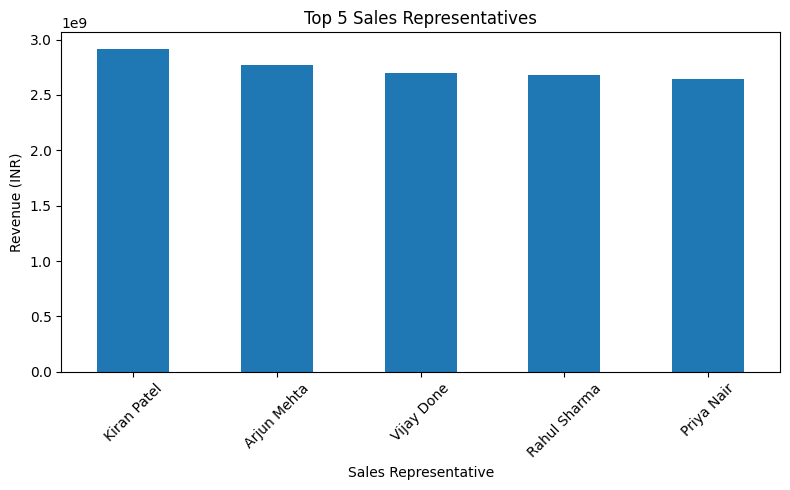

In [40]:
# Create the Bar Chart

plt.figure(figsize=(8,5))

top5_sales.plot(kind="bar")

plt.title("Top 5 Sales Representatives")

plt.xlabel("Sales Representative")

plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

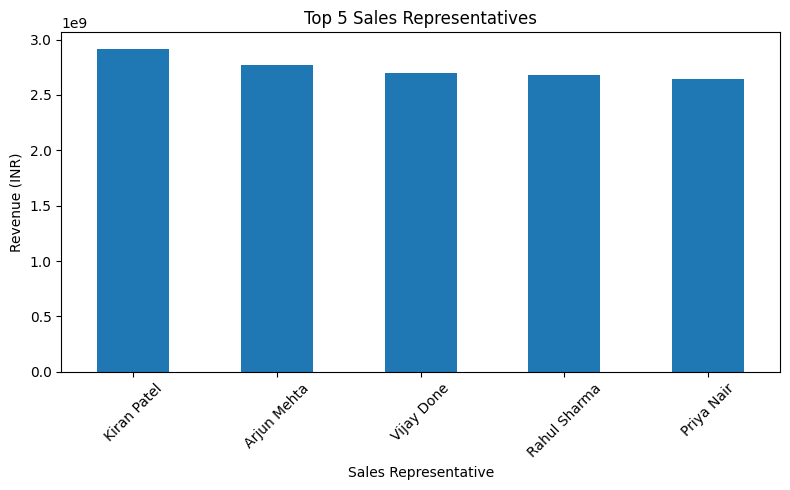

In [41]:
# Save the Chart

plt.figure(figsize=(8,5))

top5_sales.plot(kind="bar")

plt.title("Top 5 Sales Representatives")

plt.xlabel("Sales Representative")

plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/top_sales_rep.png")

plt.show()

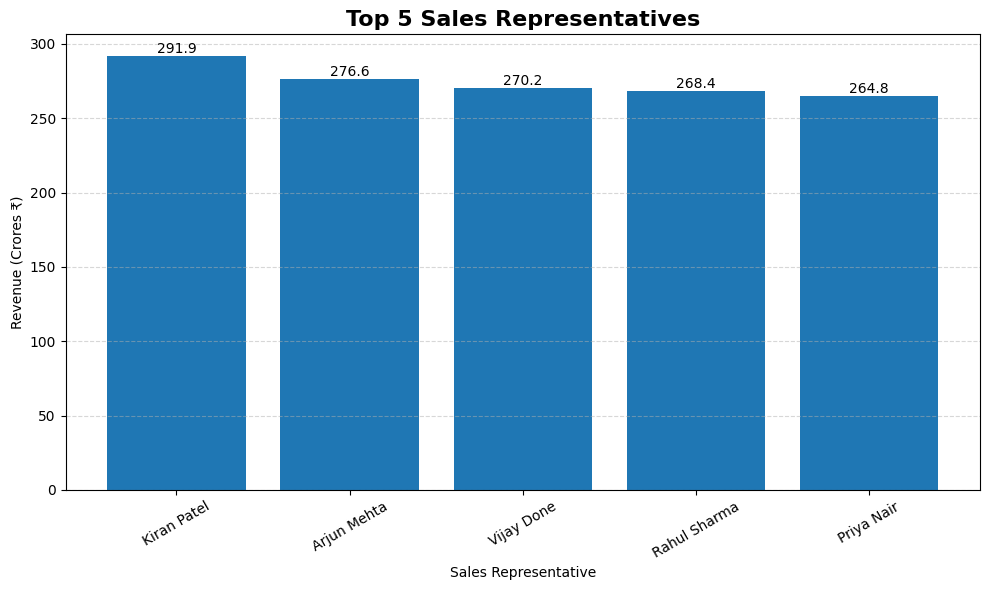

In [42]:
# Top 5 Sales Representatives

# Import matplotlib
import matplotlib.pyplot as plt

# Top 5 Sales Representatives
top5_sales = (
    df_clean.groupby("Sales_Rep")["Booking_Value_INR"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Create chart
plt.figure(figsize=(10,6))

bars = plt.bar(
    top5_sales.index,
    top5_sales.values/10000000   # Convert to Crores
)

plt.title("Top 5 Sales Representatives", fontsize=16, fontweight="bold")
plt.xlabel("Sales Representative")
plt.ylabel("Revenue (Crores ₹)")

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# Save chart
plt.savefig("../images/top_sales_rep.png", dpi=300)

plt.show()

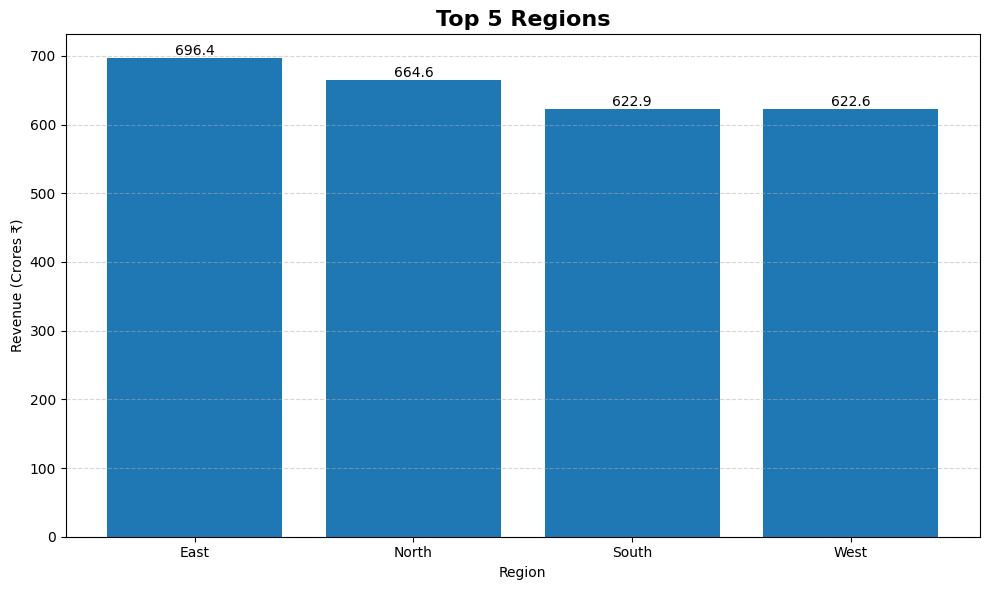

In [43]:
# Top Regions

# Top 5 Regions
top5_regions = (
    df_clean.groupby("Region")["Booking_Value_INR"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top5_regions.index,
    top5_regions.values/10000000
)

plt.title("Top 5 Regions", fontsize=16, fontweight="bold")

plt.xlabel("Region")
plt.ylabel("Revenue (Crores ₹)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/top_regions.png", dpi=300)

plt.show()


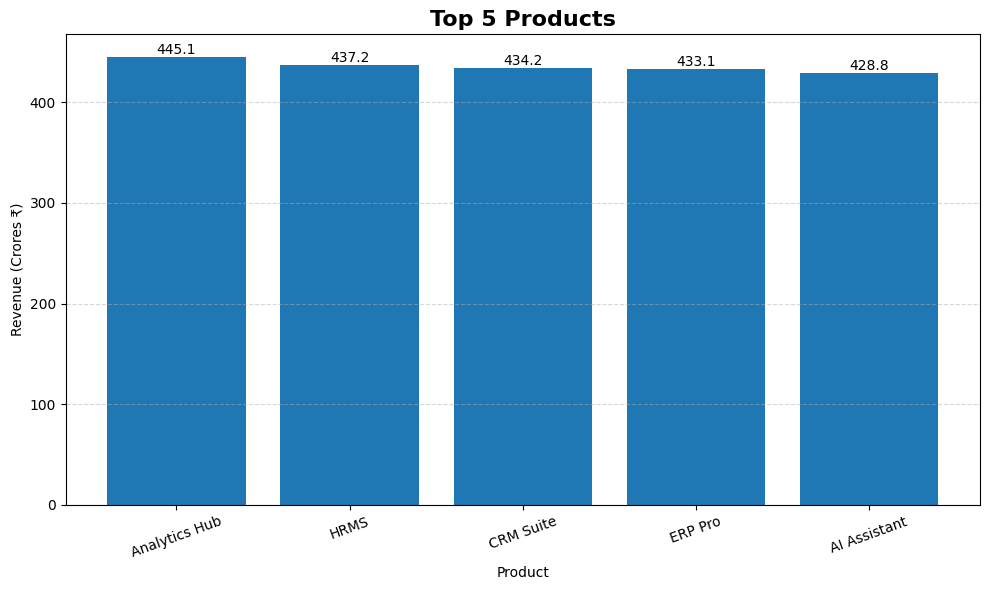

In [44]:
# Top Products

# Top 5 Products
top5_products = (
    df_clean.groupby("Product")["Booking_Value_INR"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top5_products.index,
    top5_products.values/10000000
)

plt.title("Top 5 Products", fontsize=16, fontweight="bold")

plt.xlabel("Product")
plt.ylabel("Revenue (Crores ₹)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../images/top_products.png", dpi=300)

plt.show()


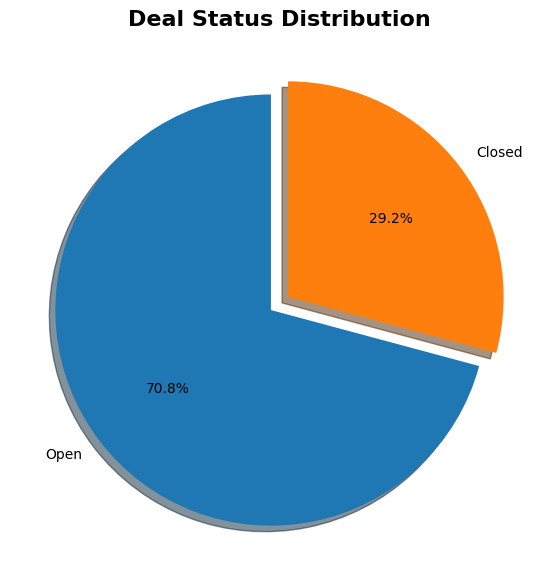

In [50]:
# Deal Status Distribution

deal_status = (
    df_clean["Deal_Status"]
    .value_counts()
)

plt.figure(figsize=(7,7))

colors = ["#4CAF50", "#FF7043"]

plt.pie(
    deal_status,
    labels=deal_status.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(deal_status),
    shadow=True
)

plt.title("Deal Status Distribution", fontsize=16, fontweight="bold")

plt.savefig("../images/deal_status.png", dpi=300)

plt.show()

In [51]:
df_clean["Deal_Status"].value_counts()

Open      3541
Closed    1459
Name: Deal_Status, dtype: int64

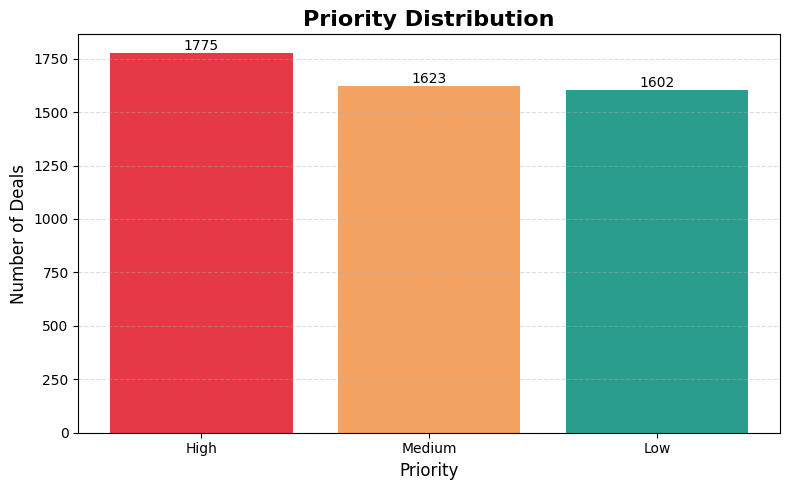

In [52]:
# Priority Distribution

priority = (
    df_clean["Priority"]
    .value_counts()
)

plt.figure(figsize=(8,5))

colors = ["#E63946", "#F4A261", "#2A9D8F"]

bars = plt.bar(
    priority.index,
    priority.values,
    color=colors
)

plt.title("Priority Distribution", fontsize=16, fontweight="bold")

plt.xlabel("Priority", fontsize=12)
plt.ylabel("Number of Deals", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("../images/priority_distribution.png", dpi=300)

plt.show()

In [53]:
df_clean["Current_Stage"].value_counts()

Won            732
Lost           727
Qualified      723
Discovery      716
Negotiation    713
Prospecting    712
Proposal       677
Name: Current_Stage, dtype: int64

In [54]:
# Win vs Lost Deals

win_lost = (
    df_clean[df_clean["Current_Stage"].isin(["Won", "Lost"])]
    ["Current_Stage"]
    .value_counts()
)

win_lost

Won     732
Lost    727
Name: Current_Stage, dtype: int64

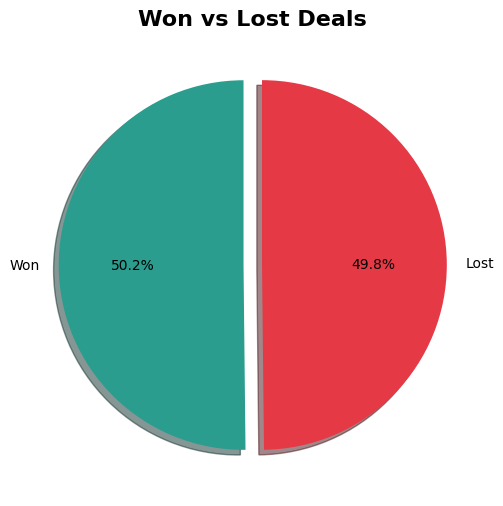

In [ ]:
# Win Vs Lost Deals

plt.figure(figsize=(6,6))

colors = ["#2A9D8F", "#E63946"]

plt.pie(
    win_lost,
    labels=win_lost.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05],
    colors=colors,
    shadow=True
)

plt.title(
    "Won vs Lost Deals",
    fontsize=16,
    fontweight="bold"
)

plt.savefig("../images/win_lost.png", dpi=300)

plt.show()